Epoch 0 | Disc Loss: 0.8886 | Gen Loss: 0.5966
Epoch 1000 | Disc Loss: 0.6903 | Gen Loss: 0.6664
Epoch 2000 | Disc Loss: 0.6870 | Gen Loss: 0.7018
Epoch 3000 | Disc Loss: 0.6940 | Gen Loss: 0.6665
Epoch 4000 | Disc Loss: 0.6959 | Gen Loss: 0.7737

Generated samples (should be near 4.0):
tensor([[5.0797],
        [4.0862],
        [4.1950],
        [4.1130],
        [3.9464]], grad_fn=<AddmmBackward0>)


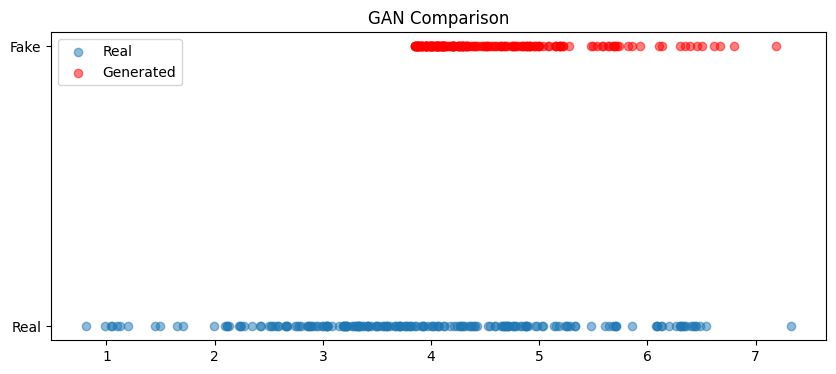

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from matplotlib import pyplot as plot

# 1. THE DATA: A simple bell curve (Gaussian distribution)
def get_real_samples(n=100):
    # Mean of 4.0, Standard Deviation of 1.25
    return torch.randn(n, 1) * 1.25 + 4.0

# 2. THE GENERATOR: Tries to turn random noise into the bell curve
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(1, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )
    def forward(self, x):
        return self.model(x)

# 3. THE DISCRIMINATOR: Tries to tell real data from fake generator data
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(1, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid() # Output is probability (0=fake, 1=real)
        )
    def forward(self, x):
        return self.model(x)

# 4. TRAINING SETUP
gen = Generator()
disc = Discriminator()
opt_gen = optim.Adam(gen.parameters(), lr=0.001)
opt_disc = optim.Adam(disc.parameters(), lr=0.001)
loss_fn = nn.BCELoss()

# 5. TRAINING LOOP
for epoch in range(5000):
    # Step A: Train Discriminator
    real_data = get_real_samples(64)
    noise = torch.randn(64, 1)
    fake_data = gen(noise)

    disc_real = disc(real_data)
    loss_disc_real = loss_fn(disc_real, torch.ones_like(disc_real))

    disc_fake = disc(fake_data.detach())
    loss_disc_fake = loss_fn(disc_fake, torch.zeros_like(disc_fake))

    loss_disc = (loss_disc_real + loss_disc_fake) / 2
    disc.zero_grad()
    loss_disc.backward()
    opt_disc.step()

    # Step B: Train Generator (to fool the Discriminator)
    output = disc(fake_data)
    loss_gen = loss_fn(output, torch.ones_like(output)) # We want Disc to think it's Real (1)

    gen.zero_grad()
    loss_gen.backward()
    opt_gen.step()

    if epoch % 1000 == 0:
        print(f"Epoch {epoch} | Disc Loss: {loss_disc:.4f} | Gen Loss: {loss_gen:.4f}")

# TEST: Generate a sample
final_noise = torch.randn(5, 1)
generated_samples = gen(final_noise)
print("\nGenerated samples (should be near 4.0):")
print(generated_samples)

# 1. Prepare data (convert to numpy for plotting)
real_plot = get_real_samples(200).numpy()
fake_plot = gen(torch.randn(200, 1)).detach().numpy()

# 2. Create the scatter plot
plot.figure(figsize=(10, 4))
plot.scatter(real_plot, np.zeros_like(real_plot), alpha=0.5, label='Real')
plot.scatter(fake_plot, np.ones_like(fake_plot), alpha=0.5, label='Generated', color='red')

# 3. Add labels and formatting
plot.title("GAN Comparison")
plot.yticks([0, 1], ["Real", "Fake"])
plot.legend()
plot.show()


In [2]:
!pip install onnx onnx-tf


In [3]:
!pip install onnx onnxscript


In [4]:
import torch

# 1. Set model to evaluation mode
gen.eval()

# 2. Create a dummy input matching your noise shape (batch_size=1, input_size=1)
dummy_input = torch.randn(1, 1)

# 3. Export to ONNX
torch.onnx.export(gen, dummy_input, "generator.onnx",
                  input_names=['input'],
                  output_names=['output'],
                  dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}})


/tmp/ipykernel_10928/1788032151.py:10: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(gen, dummy_input, "generator.onnx",


[torch.onnx] Obtain model graph for `Generator([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `Generator([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 20},
            producer_name='pytorch',
            producer_version='2.10.0+cpu',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"input"<FLOAT,[batch_size,1]>
            ),
            outputs=(
                %"output"<FLOAT,[batch_size,1]>
            ),
            initializers=(
                %"model.0.weight"<FLOAT,[16,1]>{TorchTensor(...)},
                %"model.0.bias"<FLOAT,[16]>{TorchTensor(...)},
                %"model.2.weight"<FLOAT,[1,16]>{TorchTensor(...)},
                %"model.2.bias"<FLOAT,[1]>{TorchTensor<FLOAT,[1]>(Parameter containing: tensor([0.0635], requires_grad=True), name='model.2.bias')}
            ),
        ) {
            0 |  # node_linear
                 %"linear"<FLOAT,[batch_size,16]> ⬅️ ::Gemm(%"input", %"model.0.weight"{...}, %"model.0.bias"{...}

In [5]:
!pip install ai-edge-torch-nightly


In [12]:
# 1. Install the ONLY tool you need (this takes ~30 seconds)
!pip install ai-edge-torch-nightly

import ai_edge_torch
import torch

# 2. Set your model to evaluation mode
gen.eval()

# 3. Create a dummy input (matching your noise input: 1 batch, 1 value)
sample_input = (torch.randn(1, 1),)

# 4. Convert directly to TFLite (Bypasses ONNX entirely)
edge_model = ai_edge_torch.convert(gen, sample_input)

# 5. Save the file
edge_model.export("generator.tflite")

print("Success! You can find 'generator.tflite' in the folder icon on the left.")


NotFoundError: /usr/local/lib/python3.12/dist-packages/tensorflow/core/kernels/libtfkernel_sobol_op.so: undefined symbol: _ZN10tensorflow15TensorShapeBaseINS_11TensorShapeEEC2EN4absl12lts_202308024SpanIKlEE

In [13]:
!pip install ai-edge-torch-nightly

In [15]:
# 1. Force remove all conflicting versions
!pip uninstall -y tensorflow tf-nightly ai-edge-torch-nightly onnx onnx-tf


Found existing installation: tensorflow 2.19.0
Uninstalling tensorflow-2.19.0:
  Successfully uninstalled tensorflow-2.19.0
Found existing installation: tf_nightly 2.22.0.dev20260316
Uninstalling tf_nightly-2.22.0.dev20260316:
  Successfully uninstalled tf_nightly-2.22.0.dev20260316
Found existing installation: ai-edge-torch-nightly 0.8.0.dev20260122
Uninstalling ai-edge-torch-nightly-0.8.0.dev20260122:
  Successfully uninstalled ai-edge-torch-nightly-0.8.0.dev20260122
Found existing installation: onnx 1.20.1
Uninstalling onnx-1.20.1:
  Successfully uninstalled onnx-1.20.1
Found existing installation: onnx-tf 1.6.0
Uninstalling onnx-tf-1.6.0:
  Successfully uninstalled onnx-tf-1.6.0


In [16]:
# 2. Install only the modern tools in the correct order
!pip install tensorflow
!pip install ai-edge-torch-nightly


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 1.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tf-keras 2.19.0 requires tensorflow<2.20,>=2.19, but you have tensorflow 2.21.0 which is incompatible.
tensorflow-text 2.19.0 requires tensorflow<2.20,>=2.19.0, but you have tensorflow 2.21.0 which is incompatible.
tensorflow-decision-forests 1.12.0 requires tensorflow==2.19.0, but you have tensorflow 2.21.0 which is incompatible.
  Using cached ai_edge_torch_nightly-0.8.0.dev20260122-py3-none-any.whl.metadata (2.5 kB)
  Using cached tf_nightly-2.22.0.dev20260316-cp312-cp312-manylinux_2_27_x86_64.whl.metadata (4.5 kB)
Using cached ai_edge_torch_nightly-0.8.0.dev20260122-py3-none-any.whl (523 kB)
Using cached tf_nightly-2.22.0.dev20260316-cp312-cp312-manylinux_2_27_x86_64.whl (584.8 MB)


In [2]:
!pip install torchao ai-edge-torch-nightly


In [5]:
!pip install torchao==0.4.0


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 846.8/846.8 kB 10.6 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [2]:
# 1. Install the only stable conversion bridge
!pip install onnx onnx2tf tensorflow




  Using cached onnx-1.20.1-cp312-abi3-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.4 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.6/222.6 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 5.3 MB/s eta 0:00:00
Using cached onnx-1.20.1-cp312-abi3-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (17.5 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 838.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 85.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 109.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 87.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 78.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━

NameError: name 'gen' is not defined

In [3]:
import torch
import onnx
import os

# 2. Export your Generator to ONNX (This almost always works)
gen.eval()
dummy_input = torch.randn(1, 1)
torch.onnx.export(gen, dummy_input, "model.onnx",
                  input_names=['input'], output_names=['output'])

# 3. Convert ONNX to TFLite using the 'onnx2tf' command-line tool
# This tool is much smarter than the old 'onnx-tf'
!onnx2tf -i model.onnx -o saved_model
!tflite_convert --saved_model_dir=saved_model --output_file=generator.tflite

print("\n✅ DONE! Look for 'generator.tflite' in your files sidebar.")

[torch.onnx] Obtain model graph for `Generator([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `Generator([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅

Model optimizing started ============================================================
Simplifying...
Finish! Here is the difference:
┏━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃            ┃ Original Model ┃ Simplified Model ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ Constant   │ 4              │ 4                │
│ Gemm       │ 2              │ 2                │
│ Relu       │ 1              │ 1                │
│ Model Size │ 4.9KiB         │ 698.0B           │
└────────────┴────────────────┴──────────────────┘

Simplifying...
Finish! Here is the difference:
┏━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃            ┃ Original Model ┃ Simplified Model ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ Constant   │ 4              │ 4                │
│ Gemm       │ 2              │ 2                │
│ Relu       │ 1         